<a href="https://colab.research.google.com/github/nikhilrssahu1/ML/blob/credit_card_fraud/CreditCardFraudDetection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install xgboost


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix


In [5]:
df = pd.read_csv('/content/sample_data/creditcard.csv')
print(df.head())


   Time        V1        V2        V3        V4        V5        V6        V7  \
0     0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1     0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2     1 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3     1 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4     2 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

In [6]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3973 entries, 0 to 3972
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Time    3973 non-null   int64  
 1   V1      3973 non-null   float64
 2   V2      3973 non-null   float64
 3   V3      3973 non-null   float64
 4   V4      3973 non-null   float64
 5   V5      3973 non-null   float64
 6   V6      3973 non-null   float64
 7   V7      3973 non-null   float64
 8   V8      3973 non-null   float64
 9   V9      3973 non-null   float64
 10  V10     3973 non-null   float64
 11  V11     3973 non-null   float64
 12  V12     3973 non-null   float64
 13  V13     3973 non-null   float64
 14  V14     3973 non-null   float64
 15  V15     3973 non-null   float64
 16  V16     3973 non-null   float64
 17  V17     3973 non-null   float64
 18  V18     3973 non-null   float64
 19  V19     3973 non-null   float64
 20  V20     3973 non-null   float64
 21  V21     3973 non-null   float64
 22  

In [7]:
print(df.describe())
print(df.shape)

              Time           V1           V2           V3           V4  \
count  3973.000000  3973.000000  3973.000000  3973.000000  3973.000000   
mean   1638.724138    -0.333723     0.308691     0.837062     0.013144   
std    1016.577498     1.351976     1.180436     0.981057     1.418751   
min       0.000000   -12.168192   -15.732974   -12.389545    -4.657545   
25%     750.000000    -1.030747    -0.155734     0.287224    -0.908469   
50%    1526.000000    -0.451819     0.409641     0.884503     0.099497   
75%    2526.000000     1.070572     0.921588     1.433851     0.982710   
max    3624.000000     1.685314     6.118940     4.017561     6.013346   

                V5           V6           V7           V8           V9  ...  \
count  3973.000000  3973.000000  3973.000000  3973.000000  3973.000000  ...   
mean     -0.029177     0.052836     0.146895    -0.071352     0.055778  ...   
std       1.207632     1.286610     1.090769     1.294647     0.919087  ...   
min     -32.09212

In [8]:
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [9]:
df['Class'].value_counts()
df['Class'].value_counts(normalize=True)*100

,proportion
Class,
0.0,99.949648
1.0,0.050352


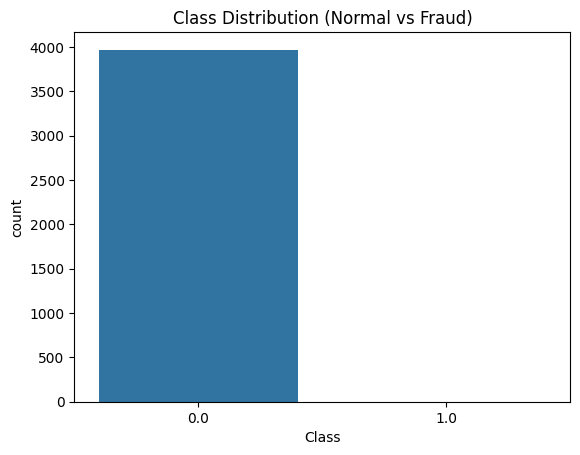

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(data=df, x='Class')
plt.title("Class Distribution (Normal vs Fraud)")
plt.show()

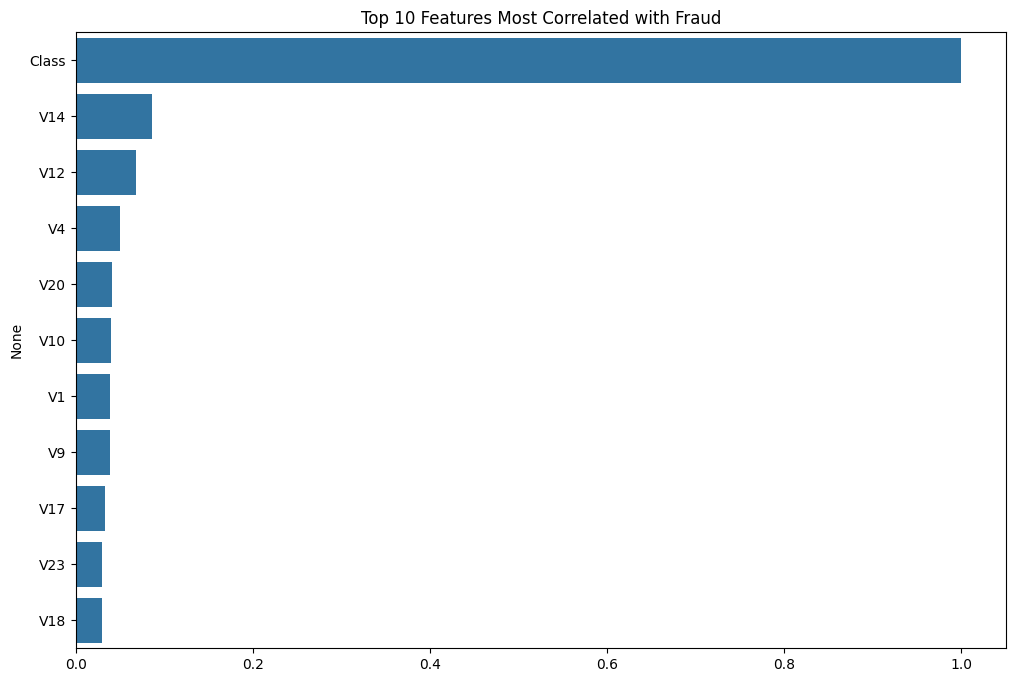

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(12,8))
corr = df.corr()["Class"].abs().sort_values(ascending=False).head(11)
sns.barplot(x=corr.values,y=corr.index)
plt.title("Top 10 Features Most Correlated with Fraud")
plt.show()